# LodeSTAR applied to dataset PhC-C2DL-PSC

<!--<badge>--><a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/examples/LodeSTAR/03.track_BF-C2DL-HSC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

In [1]:
%matplotlib inline
# !pip install deeptrack deeplay # Uncomment if running on Colab/Kaggle

In [2]:
import os

import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
from torchvision.datasets.utils import _extract_zip, download_url

### 1. Define helper functions

In [3]:
dataset_path = "cell_detection_dataset/PhC-C2DL-PSC"
if not os.path.exists(dataset_path):
    url = ("http://data.celltrackingchallenge.net/training-datasets/"
           "PhC-C2DL-PSC.zip")
    download_url(url, ".")
    _extract_zip("PhC-C2DL-PSC.zip", dataset_path, None)
    os.remove("PhC-C2DL-PSC.zip")
dir = os.path.join(dataset_path, "PhC-C2DL-PSC/01")

def load_tif_movie(tif_dir):
    """Loads Data."""
    
    tif_files = sorted([
        os.path.join(tif_dir, f) for f in os.listdir(tif_dir) if f.lower().endswith(".tif")
    ])
    frames = [np.array(Image.open(f)) for f in tif_files]
    movie = np.stack(frames, axis=0)
    return movie

def normalize_min_max(img, squeeze_in_2D=False):
    """Normalizes intensities."""
    if squeeze_in_2D:
        img = np.squeeze(img)
    max_intensity = np.max(img)
    min_intensity = np.min(img)
    if max_intensity == min_intensity:
        raise ValueError("Cannot normalize array with uniform intensity.")
    normalized_img = (img - min_intensity) / (
        max_intensity - min_intensity)
    return normalized_img

100%|██████████| 145M/145M [00:12<00:00, 12.0MB/s] 


### 2. Load data

In [4]:
movie = load_tif_movie(dir)

# Normalize.
movie = normalize_min_max(movie)
print(f"Loaded {movie.shape[0]} frames of size {movie.shape[1]}x{movie.shape[2]}")

Loaded 300 frames of size 576x720


### 3. Obtain Crop

(56, 56)


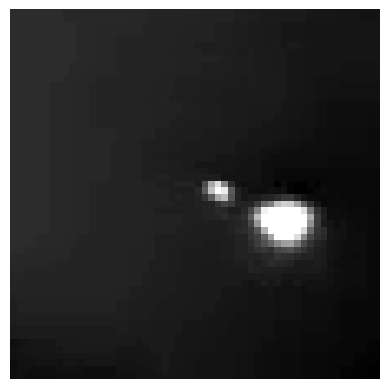

In [5]:
t, x, y, w = (0, 640, 430, 56)
crop = movie[t, y:y+w, x:x+w]
plt.imshow(crop, cmap="gray")
plt.axis("off")
print(crop.shape)

### 4. Train Model

INFO: 
  | Name          | Type                       | Params | Mode 
---------------------------------------------------------------------
0 | model         | ConvolutionalNeuralNetwork | 251 K  | train
1 | between_loss  | L1Loss                     | 0      | train
2 | within_loss   | L1Loss                     | 0      | train
3 | train_metrics | MetricCollection           | 0      | train
4 | val_metrics   | MetricCollection           | 0      | train
5 | test_metrics  | MetricCollection           | 0      | train
6 | optimizer     | Adam                       | 0      | train
---------------------------------------------------------------------
251 K     Trainable params
0         Non-trainable params
251 K     Total params
1.004     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                       | Params | Mode 
------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

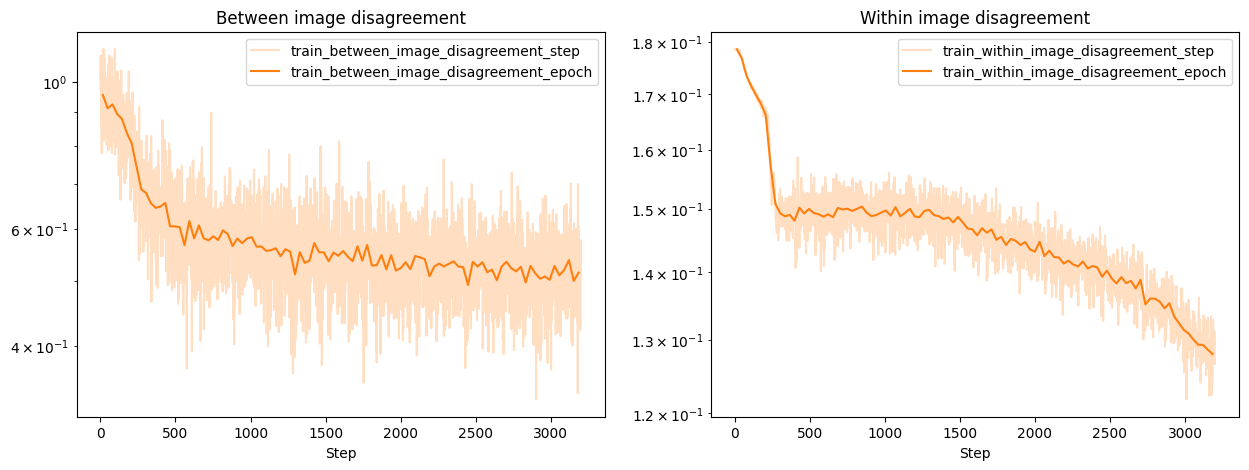

In [35]:
# Add empty batch dimension for compatability.
training_crop = crop[np.newaxis]

# Instance LodeSTAR.
model = dl.LodeSTAR(n_transforms=8, optimizer=dl.Adam(lr=1e-4)).build()

# Define training pipeline, dataset, dataloader.
training_pipeline = (
    dt.Value(training_crop)
    >> dt.Affine(rotate=lambda: np.random.rand()*np.pi*2, scale=lambda:np.random.uniform(0.75, 1.5, 2))
    >> dt.Add(lambda: np.random.randn() * 0.2)
    >> dt.Gaussian(sigma=lambda:np.random.uniform(0, 0.01))  
    >> dt.Multiply(lambda: np.random.uniform(0.3, 1.6))
    >> dt.NormalizeMinMax()
    >> dt.pytorch.ToTensor(dtype=torch.float32)
    
)
train_dataset = dt.pytorch.Dataset(
     training_pipeline,
     length=128,
     replace=False,
)
dataloader = dl.DataLoader(
     train_dataset,
     batch_size=4,
     shuffle=True,
)

# Start training.
trainer_lodestar = dl.Trainer(max_epochs=100, accelerator="cuda")
trainer_lodestar.fit(model, dataloader)

# Plot history and save weights.
trainer_lodestar.history.plot()
torch.save(model.state_dict(), "lodestar_weights_PhC-C2DL-PSC")

### 5. Test Model

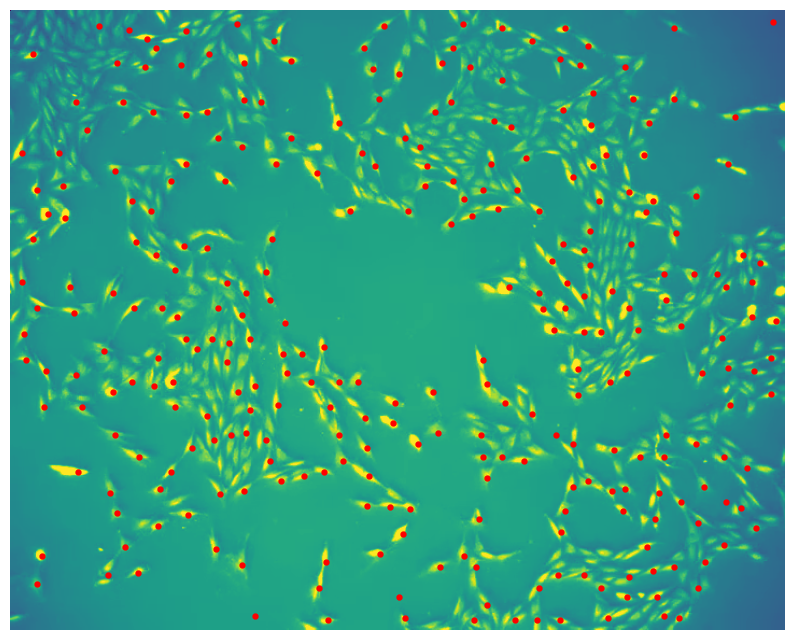

In [66]:
# May need to tune these to get optimal performance!
alpha = .9
cutoff = 0.0011

# Last frame of the movie.
frame_index = 299
image = movie[frame_index]

# Convert to tensor for LodeSTAR.
image = torch.as_tensor(
    image,
    dtype=torch.float32
).detach().unsqueeze(0).unsqueeze(0).to("cuda")

detections = model.detect(
    image,
    alpha=alpha,
    beta= 1 - alpha, 
    cutoff=cutoff,
    mode="constant"
)[0]

plt.figure(figsize=(10, 10))
plt.imshow(image.cpu()[0, 0, :, :])
plt.axis("off")
plt.scatter(detections[:, 1], detections[:, 0], s = 50,marker=".", c="r")